In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.least_squares import LinearRegression, PowerLawRegression
from src.SGD import SGD, NoisyGD
from scheduled import WSDSchedule, ConstantSchedule
from src.new_schedules.polynomial import PolynomialSchedule
from src.compute import Computations
import src.utils as utils

## Optimization $\eta$

In [4]:
T=1000
sigma = 0.1
dim = 10

eta = 0.1
n = 1000
t_values = np.linspace(0, T-1, 10, dtype=int)

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.4)
constant = ConstantSchedule(steps=T, base_lr=eta)
polynomial = PolynomialSchedule(steps=T, base_lr=eta, exponent=0.5)

computations_SGD = Computations(model, schedules=[polynomial, wsd, constant], sgd_class=SGD)
x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


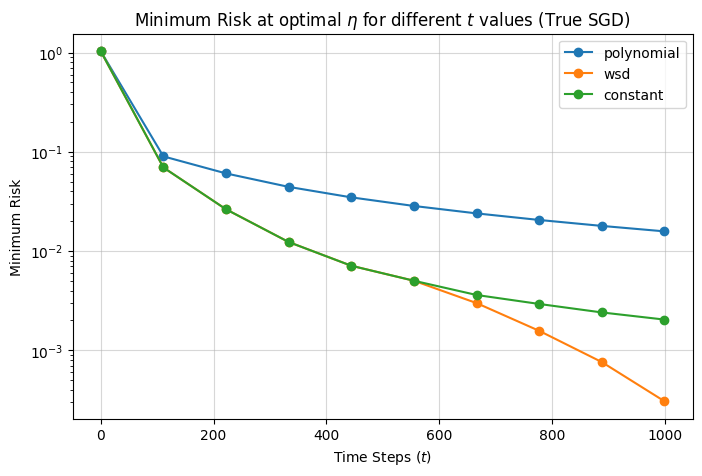

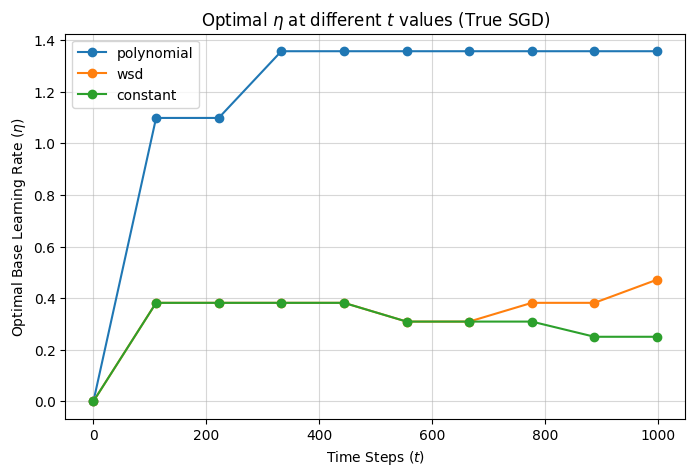

Optimization results saved to saved_files\optimize_results_at_several_ts_2026-04-14_16-01-41.json


In [3]:
risksSGD = computations_SGD.optimize_at_several_ts(x0, t_values=t_values, plot=True, change_eta=False, log_scale=True)


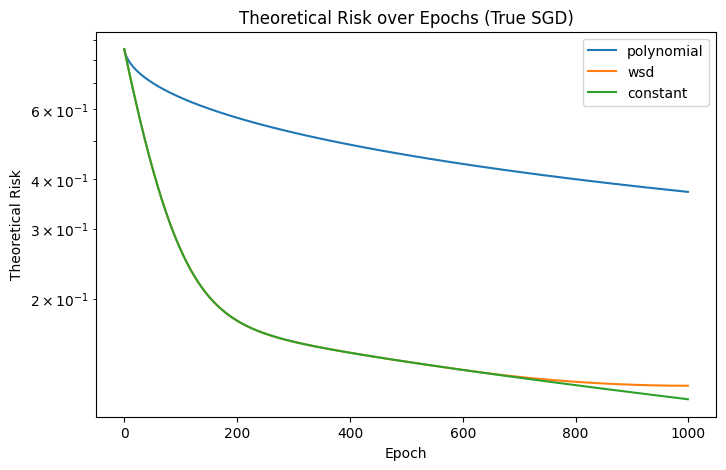

c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


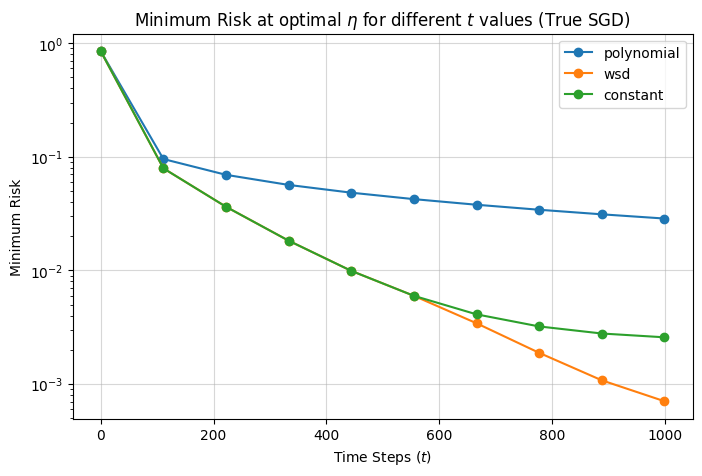

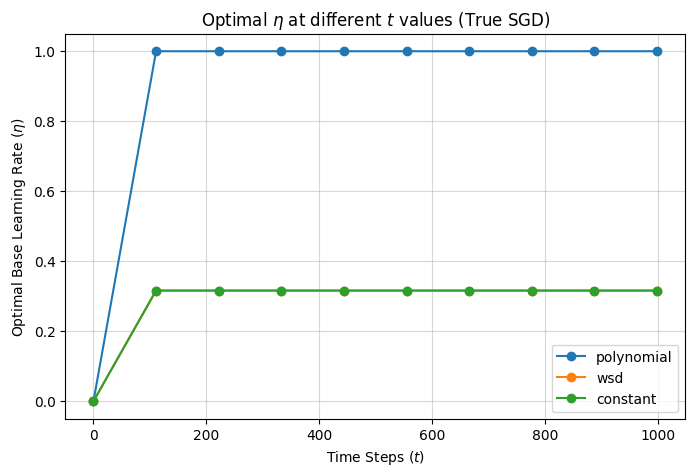

Optimization results saved to saved_files\optimize_results_at_several_ts_2026-04-14_16-08-47.json


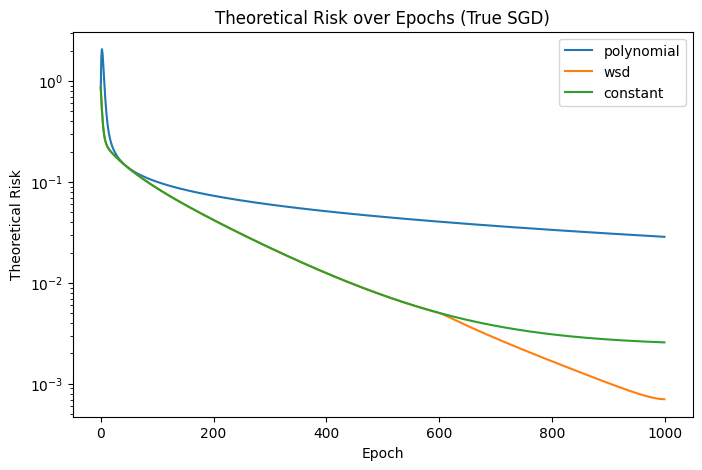

{'polynomial': array([0.85121172, 1.76384689, 2.06560279, 1.91430031, 1.6010993 ,
        1.28517863, 1.02229724, 0.82021413, 0.67010045, 0.5598951 ,
        0.47890385, 0.41884923, 0.37369437, 0.33915848, 0.31224281,
        0.29085322, 0.2735236 , 0.259221  , 0.24721118, 0.23696652,
        0.22810327, 0.22033863, 0.21346127, 0.20731108, 0.20176497,
        0.19672699, 0.19212132, 0.18788726, 0.18397557, 0.18034586,
        0.17696465, 0.17380386, 0.17083978, 0.16805216, 0.16542361,
        0.16293908, 0.16058546, 0.15835127, 0.15622639, 0.15420188,
        0.15226978, 0.150423  , 0.14865517, 0.14696057, 0.14533407,
        0.14377099, 0.14226711, 0.14081858, 0.13942191, 0.13807388,
        0.13677158, 0.1355123 , 0.13429358, 0.13311314, 0.13196887,
        0.13085884, 0.12978124, 0.12873442, 0.12771681, 0.12672697,
        0.12576358, 0.12482536, 0.12391116, 0.12301987, 0.12215048,
        0.12130203, 0.12047362, 0.11966439, 0.11887356, 0.11810037,
        0.11734411, 0.11660413, 0.

In [5]:
T=1000
sigma = 0.1
dim = 10

eta = 0.01
n = 100
t_values = np.linspace(0, T-1, 10, dtype=int)

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.4)
constant = ConstantSchedule(steps=T, base_lr=eta)
polynomial = PolynomialSchedule(steps=T, base_lr=eta, exponent=0.5)

computations_SGD = Computations(model, schedules=[polynomial, wsd, constant], sgd_class=SGD)
x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))


computations_SGD.compute_all_theoretical_risks(x0, plot=True, log_scale=True)
optimize = computations_SGD.optimize_at_several_ts(x0, t_values=t_values, eta_range=np.logspace(-4, 0.5, 10),plot=True, change_eta=True, log_scale=True)
computations_SGD.compute_all_theoretical_risks(x0, plot=True, log_scale=True)

In [ ]:
test = utils.read_optimization_results(r"optimize_results_at_several_ts_2026-04-14_16-01-41.json")
test[max(test.keys())]

computations_SGD.adapt_eta_from_file("optimize_results_at_several_ts_2026-04-14_16-01-41.json", several_ts=True)


Optimization results loaded from saved_files\optimize_results_at_several_ts_2026-04-14_16-01-41.json
Optimization results loaded from saved_files\optimize_results_at_several_ts_2026-04-14_16-01-41.json
Updated polynomial with optimal eta: 1.36e+00
Updated wsd with optimal eta: 4.71e-01
Updated constant with optimal eta: 2.50e-01


1.3572287829716538